# EDA — Univariate analyse

**Exploratieve data-analyse (EDA)** is de fase waarin je een dataset verkent vóór je modellen bouwt of conclusies trekt. Je doel is:

1. De structuur en kwaliteit van de data begrijpen
2. Distributies en patronen ontdekken
3. Anomalieën, uitschieters en ontbrekende waarden opsporen

**Univariate analyse** bestudeert **één variabele** tegelijk. In het volgende notebook voegen we de relaties tussen variabelen toe (bivariate analyse).

We gebruiken de **Titanic-dataset** als leidraad.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Stap 1: Eerste verkenning

Begin altijd met een snelle scan van de dataset.

In [2]:
# Summary of types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## Stap 2: Ontbrekende waarden analyseren

In [4]:
# Overview of missing values
missing = pd.DataFrame(
    {
        "n_missing": df.isnull().sum(),
        "pct_missing": (df.isnull().mean() * 100).round(1),
    }
)
missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)

,n_missing,pct_missing
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


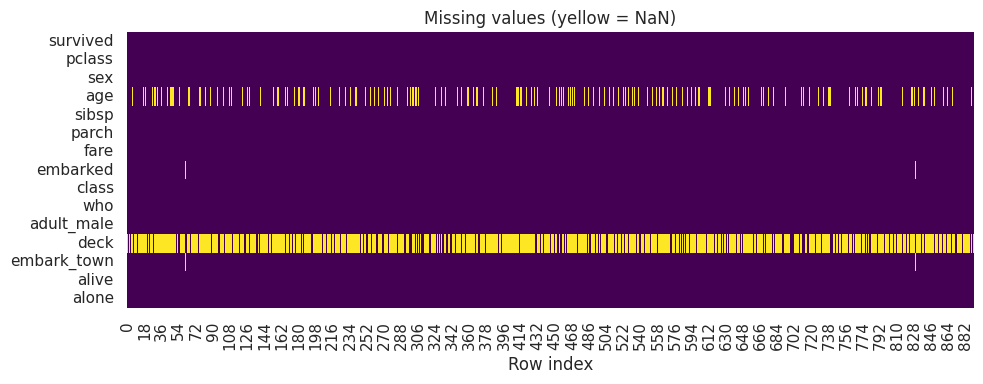

In [5]:
# Visualise missing values as a heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df.isnull().T,
    cbar=False,
    cmap="viridis",
    ax=ax,
    yticklabels=True,
)
ax.set_title("Missing values (yellow = NaN)")
ax.set_xlabel("Row index")
plt.tight_layout()
plt.show()

## Stap 3: Numerieke variabelen — distributie-analyse
Een analyse van de datadistributie of -verdeling houdt in dat je nagaat hoe de hoeveelheid data verspreid ligt over de verschillende waarden van een variabele.

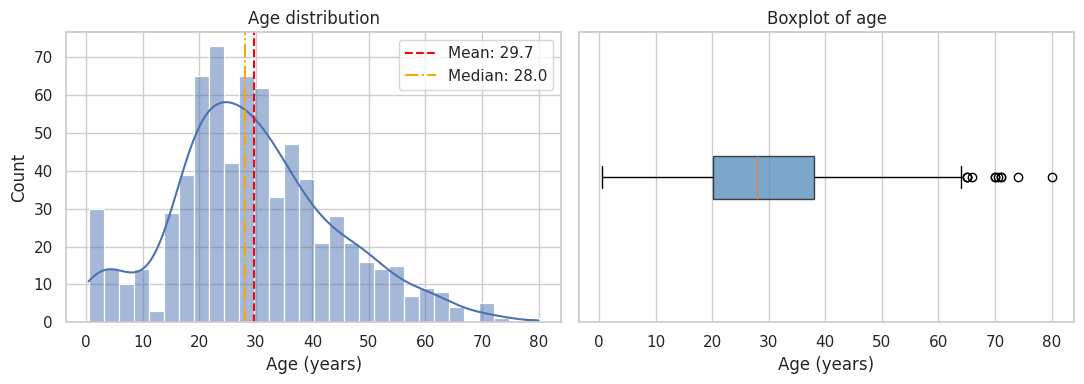

In [6]:
# Distribution of age
ages = df["age"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram with KDE
sns.histplot(ages, bins=30, kde=True, ax=axes[0])
axes[0].axvline(ages.mean(), color="red", linestyle="--", label=f"Mean: {ages.mean():.1f}")
axes[0].axvline(ages.median(), color="orange", linestyle="-.", label=f"Median: {ages.median():.1f}")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")
axes[0].legend()

# Boxplot
axes[1].boxplot(
    ages, vert=False, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7)
)
axes[1].set_title("Boxplot of age")
axes[1].set_xlabel("Age (years)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [7]:
# Descriptive statistics
print(f"Mean:              {ages.mean():.2f}")
print(f"Median:            {ages.median():.2f}")
print(f"Std deviation:     {ages.std():.2f}")
print(f"Skewness:          {ages.skew():.2f}")
print(f"Kurtosis:          {ages.kurtosis():.2f}")

Mean:              29.70
Median:            28.00
Std deviation:     14.53
Skewness:          0.39
Kurtosis:          0.18


## Stap 4: Uitschieters detecteren — IQR-methode

Er bestaan verschillende heuristieken om te bepalen of een waarde al dan niet als een **uitschieter** of *outlier* beschouwd moet worden. Een zo'n methode maakt gebruik van de [interkwartielafstand](https://en.wikipedia.org/wiki/Interquartile_range) (IQR) en beschouwt waarden als outliers als ze meer dan x-keer (bv. 1,5) de IQR verwijderd zijn van het eerste of derde kwartiel.

In [8]:
def iqr_outliers(series):
    """Return a boolean mask of outliers using the IQR method."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)


fares = df["fare"].dropna()
mask = iqr_outliers(fares)
print(f"Outliers in 'fare': {mask.sum()} ({mask.mean() * 100:.1f}%)")
print(f"Maximum ticket price: £{fares.max():.2f}")

Outliers in 'fare': 116 (13.0%)
Maximum ticket price: £512.33


In [9]:
# Visualise outliers
fig = px.box(
    df,
    y="fare",
    points="all",
    title="Ticket prices — outliers visible",
    labels={"fare": "Price (£)"},
)
fig.show()

## Stap 5: Categorische variabelen

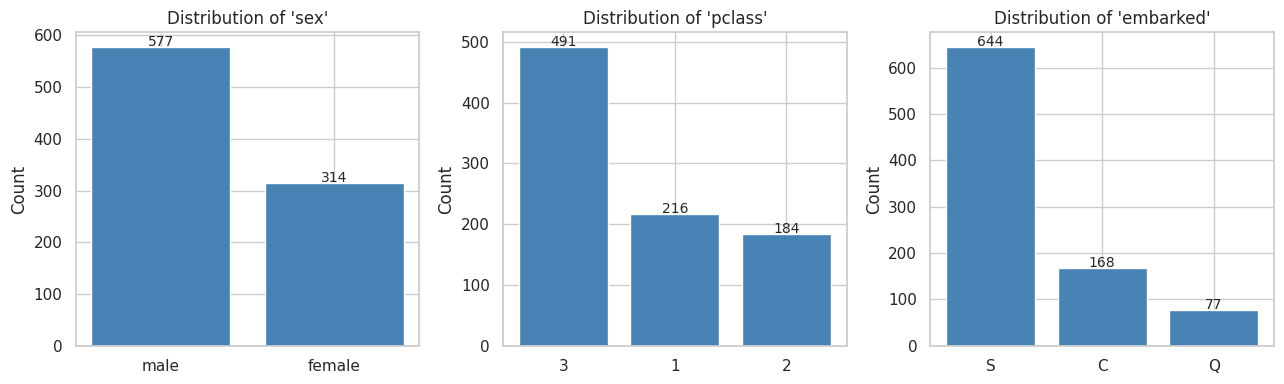

In [10]:
# Distribution of each categorical variable
categorical_cols = ["sex", "pclass", "embarked"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, column in zip(axes, categorical_cols):
    counts = df[column].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of '{column}'")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Check class balance (target variable)
print(df["survived"].value_counts())
print()
print(df["survived"].value_counts(normalize=True).round(3))

survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Overzicht van alle numerieke variabelen

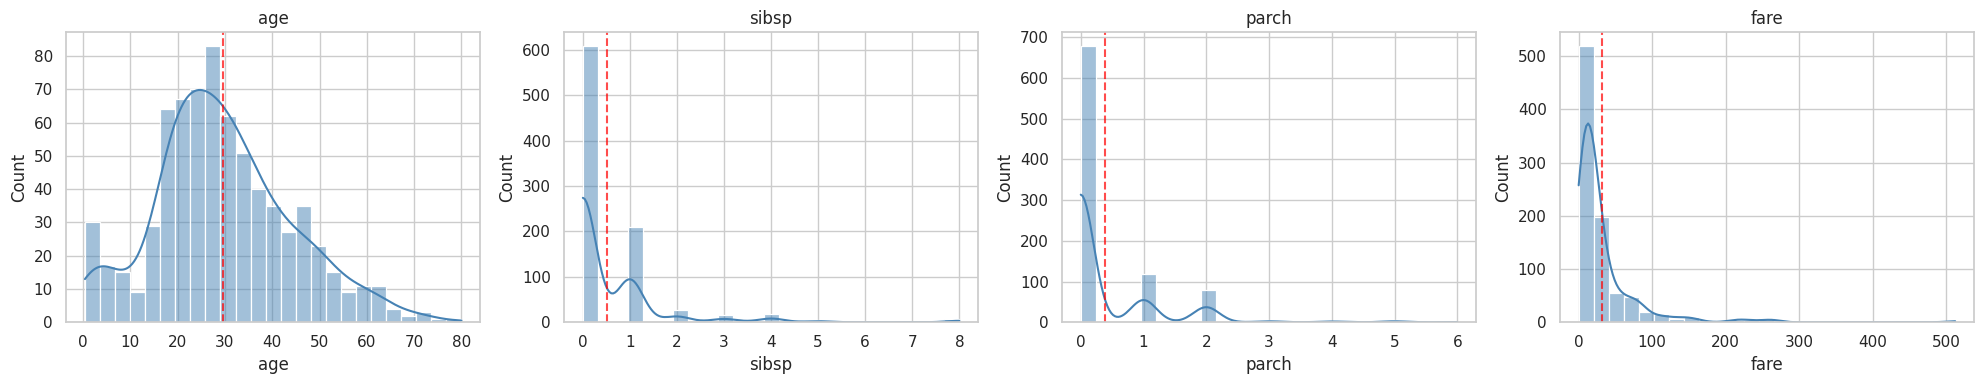

In [12]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if df[c].nunique() > 5]  # exclude binary discrete vars

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))

for ax, column in zip(axes, numeric_cols):
    data = df[column].dropna()
    sns.histplot(data, bins=25, kde=True, ax=ax, color="steelblue")
    ax.axvline(data.mean(), color="red", linestyle="--", alpha=0.7)
    ax.set_title(column)

plt.tight_layout()
plt.show()

---

## Oefeningen

Gebruik de **Penguins-dataset**: `sns.load_dataset("penguins")`.

In [13]:
penguins = sns.load_dataset("penguins")

**Oefening 1** — Maak een overzicht van ontbrekende waarden (absoluut en percentage). Welke kolom heeft het meeste ontbrekende data?

In [14]:
# your solution here

**Oefening 2** — Maak voor `flipper_length_mm` een histogram met KDE-curve en markeer het gemiddelde en de mediaan als verticale lijnen. Beschrijf de vorm van de distributie in een markdown-cel.

In [15]:
# your solution here

*Description:*

**Oefening 3** — Gebruik de IQR-methode om uitschieters te detecteren in `body_mass_g`. Hoeveel uitschieters zijn er? Visualiseer met een Plotly boxplot.

In [16]:
# your solution here

**Oefening 4** — Maak een staafdiagram van de verdeling van `island` (gebruik Plotly). Welk eiland heeft de meeste pinguïns in de dataset? Is de dataset gebalanceerd?

In [17]:
# your solution here